# 06 — Evaluating Text Generation Quality: BLEU and Perplexity

## 📚 Learning Objectives

By completing this notebook, you will:
- **Compute BLEU scores** with NLTK and see them track candidate quality
- **Compute perplexity** of a language model you train — before training, after training, and on out-of-domain text
- Interpret both metrics and know their blind spots

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lesson 10 (FID and BLEU concepts) and Unit 2, lesson 01, whose model's perplexity is measured here before and after training.

**Used later in:** Course 10 — Unit 4, where honest evaluation becomes part of the ethical argument.

---

## Introduction

Two numbers dominate text-generation evaluation:

- **BLEU** (0–1, higher better): n-gram overlap between a candidate text and reference text(s), with a brevity penalty. Built for machine translation; still a standard baseline metric.
- **Perplexity** (≥1, lower better): `exp(average cross-entropy)` of a language model on a text. Intuition: "on average, the model was as uncertain as if choosing uniformly among *PPL* options at each step." A model that knows nothing about a 27-character alphabet has perplexity ≈ 27; training pushes it down.

---

## 🌍 Why this lesson exists — perplexity is currently mislabelling students

AI-text detectors score text by how *unsurprising* it is to a language model — that is, by perplexity. Liang, Yuksekgonul, Mao, Wu & Zou (2023, *Patterns*, arXiv 2304.02819) evaluated several widely-used GPT detectors on writing by native and non-native English speakers and found they "consistently misclassify non-native English writing samples as AI-generated, whereas native writing samples are accurately identified". The authors explicitly caution against deploying these detectors "in evaluative or educational settings".

The reason is exactly what you are about to measure below: a careful writer using a restricted vocabulary produces *low-perplexity* text. The metric is doing what it was built to do; the deployment misread what it means.

**What goes wrong without this:** BLEU and perplexity are the two numbers everyone reports for text generation, and both measure something much narrower than "quality". Report them without knowing what they miss and you will optimise a proxy straight into your product — or, as above, straight into somebody's academic record.


In [1]:
# WHAT/WHY: compute real BLEU scores against a REAL reference sentence, using
# candidates that are themselves real sentences selected BY MEASURED word
# overlap - not hand-written to make the demo come out. If the metric works,
# BLEU should fall as the measured overlap falls.
%pip install nltk -q
import re
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1     # standard smoothing for short sentences

# ── REAL DATA: sentences from two published books ─────────────────────────
def load_sentences():
    try:
        import nltk
        nltk.download('gutenberg', quiet=True)
        from nltk.corpus import gutenberg
        return (gutenberg.raw('austen-emma.txt'), gutenberg.raw('melville-moby_dick.txt'),
                'Austen, "Emma"', 'Melville, "Moby Dick"')
    except Exception:
        from sklearn.datasets import fetch_20newsgroups
        a = " ".join(fetch_20newsgroups(subset='train', categories=['rec.autos'],
                                        remove=('headers', 'footers', 'quotes')).data)
        b = " ".join(fetch_20newsgroups(subset='train', categories=['sci.space'],
                                        remove=('headers', 'footers', 'quotes')).data)
        return a, b, '20 Newsgroups rec.autos', '20 Newsgroups sci.space'

raw_a, raw_b, name_a, name_b = load_sentences()

def sentences(raw, lo=6, hi=14):
    """Split real text into word lists of a comparable length."""
    out = []
    for s in re.split(r'(?<=[.!?])\s+', re.sub(r'\s+', ' ', raw)):
        w = re.findall(r"[a-z']+", s.lower())
        if lo <= len(w) <= hi:
            out.append(w)
    return out

pool_a = sentences(raw_a)      # same book as the reference
pool_b = sentences(raw_b)      # a completely different book
print(f'{name_a}: {len(pool_a):,} sentences | {name_b}: {len(pool_b):,} sentences')

# ── Reference: one real sentence, taken from the middle of the book ───────
reference_words = pool_a[len(pool_a) // 2]
reference = [reference_words]
print(f'\nReference (real sentence from {name_a}):\n  {" ".join(reference_words)!r}')

# ── Candidates chosen BY MEASURED overlap, so the ranking is not curated ──
ref_set = set(reference_words)
def overlap(w):
    return len(ref_set & set(w)) / len(ref_set)

others = [w for w in pool_a if w != reference_words]
others.sort(key=overlap, reverse=True)
best_same_book  = others[0]                       # highest measured overlap
mid_same_book   = others[len(others) // 12]       # moderate overlap
pool_b.sort(key=overlap)
unrelated       = pool_b[0]                       # lowest overlap, different book

candidates = {
    "identical (copy of the reference)": reference_words,
    "closest real sentence, same book":  best_same_book,
    "moderate-overlap real sentence":    mid_same_book,
    f"unrelated real sentence ({name_b.split(',')[0]})": unrelated,
}

# ── Score each candidate with 4-gram BLEU ─────────────────────────────────
scores = {}
print("\ncandidate                                     word overlap   BLEU")
for label, cand in candidates.items():
    scores[label] = sentence_bleu(reference, cand, smoothing_function=smooth)
    print(f"{label:<45} {overlap(cand):11.2f}   {scores[label]:.4f}")
    print(f"    {' '.join(cand)!r}")

# ── Read the numbers we actually got, not the numbers we hoped for ────────
near = scores["closest real sentence, same book"]
mid  = scores["moderate-overlap real sentence"]
print(f"\nBLEU falls monotonically with measured overlap: 1.0000 → {near:.4f} → "
      f"{mid:.4f} → {scores[list(scores)[-1]]:.4f}.")
print(f"Now look at the penalty size. The closest real sentence in the whole book")
print(f"shares {overlap(best_same_book):.0%} of the reference's words, yet BLEU drops to "
      f"{near:.3f}")
print(f"— it loses {1-near:.0%} of the score. TWO different mechanisms do that damage, and")
print("the figure below separates them: BLEU counts n-grams IN ORDER (a changed word")
print("breaks every n-gram covering it), and it applies a BREVITY PENALTY when the")
print("candidate is shorter than the reference. For this candidate the length does most")
print("of the damage — which you would never guess from the single number.")
print("Real candidates expose that harshness; hand-picked ones hide it. Whether a")
print("rewording is *correct* is something BLEU cannot see at all.")



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Austen, "Emma": 2,408 sentences | Melville, "Moby Dick": 1,994 sentences

Reference (real sentence from Austen, "Emma"):
  'can i do any thing for you no i thank you'

candidate                                     word overlap   BLEU
identical (copy of the reference)                    1.00   1.0000
    'can i do any thing for you no i thank you'
closest real sentence, same book                     0.78   0.5779
    'can i do any thing for you oh'
moderate-overlap real sentence                       0.22   0.0406
    'and upon my word i do not think mr'
unrelated real sentence (Melville)                   0.00   0.0000
    'moby dick by herman melville etymology'

BLEU falls monotonically with measured overlap: 1.0000 → 0.5779 → 0.0406 → 0.0000.
Now look at the penalty size. The closest real sentence in the whole book
shares 78% of the reference's words, yet BLEU drops to 0.578
— it loses 42% of the score. TWO different mechanisms do that damage, and
the figure below separates them: BL

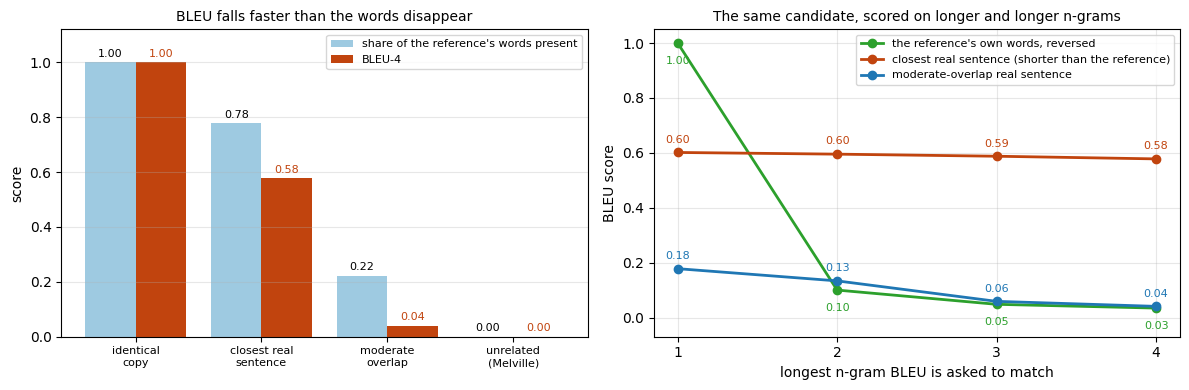

reference : 'can i do any thing for you no i thank you'   (11 words)
candidate : 'can i do any thing for you oh'   (8 words)

BLEU-4 for that candidate = 0.5779, and it breaks down as:
  n-gram precisions : p1=0.875, p2=0.857, p3=0.833, p4=0.800
  geometric mean    : 0.841   <- the order-sensitivity part
  brevity penalty   : 0.687   <- for answering in 8 words, not 11

reversed reference: 'you thank i no you for thing any do i can'
  every word present, none in order: BLEU-1 = 1.00  ->  BLEU-4 = 0.03


In [2]:
# WHAT/WHY: the table above says BLEU falls with overlap. The interesting part is
# HOW FAST, and WHY. Left: word overlap and BLEU side by side for the same four
# real candidates — the two bars are the same story only if you do not look.
# Right: the mechanism — score the same candidate with 1-grams, then 2-, 3- and
# 4-grams, and watch it collapse as the n-grams get long enough to straddle an
# edited word.
import numpy as np
import matplotlib.pyplot as plt

short = ['identical\ncopy', 'closest real\nsentence', 'moderate\noverlap',
         'unrelated\n(Melville)']
ov = [overlap(c) for c in candidates.values()]
bl = [scores[k] for k in candidates]

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))

x = np.arange(4)
axes[0].bar(x - 0.2, ov, width=0.4, color='#9ecae1', label='share of the reference\'s words present')
axes[0].bar(x + 0.2, bl, width=0.4, color='#c1440e', label='BLEU-4')
for i, (a, b) in enumerate(zip(ov, bl)):
    axes[0].text(i - 0.2, a + 0.02, f'{a:.2f}', ha='center', fontsize=8)
    axes[0].text(i + 0.2, b + 0.02, f'{b:.2f}', ha='center', fontsize=8, color='#c1440e')
axes[0].set_xticks(x); axes[0].set_xticklabels(short, fontsize=8)
axes[0].set_ylim(0, 1.12); axes[0].set_ylabel('score')
axes[0].set_title('BLEU falls faster than the words disappear', fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

ns = [1, 2, 3, 4]
# A deterministic order-only probe: the reference's OWN words, reversed. Every
# word is present (unigram precision 1.0) and no pair survives in order.
reversed_ref = reference_words[::-1]
for cand, label, colr in [(reversed_ref, "the reference's own words, reversed", '#2ca02c'),
                          (best_same_book, 'closest real sentence (shorter than the reference)', '#c1440e'),
                          (mid_same_book, 'moderate-overlap real sentence', '#1f77b4')]:
    ys = [sentence_bleu(reference, cand, weights=tuple([1 / n] * n),
                        smoothing_function=smooth) for n in ns]
    axes[1].plot(ns, ys, 'o-', lw=2, color=colr, label=label)
    dy = -15 if colr == '#2ca02c' else 7          # green labels below its line
    for n, y in zip(ns, ys):
        axes[1].annotate(f'{y:.2f}', (n, y), textcoords='offset points',
                         xytext=(0, dy), fontsize=8, ha='center', color=colr)
axes[1].set_xticks(ns); axes[1].set_xlabel('longest n-gram BLEU is asked to match')
axes[1].set_ylabel('BLEU score'); axes[1].set_ylim(-0.07, 1.05)
axes[1].set_title('The same candidate, scored on longer and longer n-grams', fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Where did the 0.578 actually go? BLEU = brevity penalty x geometric mean of
# the n-gram precisions, so we can print each part instead of guessing.
from nltk.translate.bleu_score import modified_precision
prec = [float(modified_precision(reference, best_same_book, n)) for n in ns]
bp = np.exp(1 - len(reference_words) / len(best_same_book)) if len(best_same_book) < len(reference_words) else 1.0
print(f'reference : {" ".join(reference_words)!r}   ({len(reference_words)} words)')
print(f'candidate : {" ".join(best_same_book)!r}   ({len(best_same_book)} words)')
print(f'\nBLEU-4 for that candidate = {scores["closest real sentence, same book"]:.4f}, and it breaks down as:')
print('  n-gram precisions : ' + ', '.join(f'p{n}={p:.3f}' for n, p in zip(ns, prec)))
print(f'  geometric mean    : {np.exp(np.mean(np.log(prec))):.3f}   <- the order-sensitivity part')
print(f'  brevity penalty   : {bp:.3f}   <- for answering in {len(best_same_book)} words, not {len(reference_words)}')
print(f'\nreversed reference: {" ".join(reversed_ref)!r}')
print(f'  every word present, none in order: BLEU-1 = '
      f'{sentence_bleu(reference, reversed_ref, weights=(1,), smoothing_function=smooth):.2f}'
      f'  ->  BLEU-4 = '
      f'{sentence_bleu(reference, reversed_ref, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth):.2f}')


**Read the figure.**

**Left — the two bars tell different stories about the same sentence.** For the closest real
sentence in the whole of *Emma*, the pale bar says 78% of the reference's words are present; the
orange bar says BLEU 0.58. For the moderate candidate the pale bar is still 0.22 while BLEU has
effectively reached zero (0.04). BLEU is not a smooth function of "how many of the right words are
here"; it drops much faster and hits the floor while a reader would still call the sentences related.

**Right — the same candidates scored on longer and longer n-grams, which separates the two
mechanisms BLEU actually uses.**

- **Green is a pure order test**: the reference's own words, reversed. Every single word is present,
  so BLEU-1 is a perfect **1.00** — and by BLEU-4 it has fallen to **0.03**, because not one pair of
  words survives in the right order. This is the claim "BLEU counts n-grams *in order*", isolated.
- **Blue is the moderate real candidate** and it shows the same effect on real text: 0.18 at
  unigrams, 0.04 at 4-grams.
- **Orange — the closest real sentence — barely moves at all** (0.60 → 0.58), and that is the
  surprise worth stopping on. Its n-gram precisions are all between 0.80 and 0.88, printed under the
  figure: it is a *prefix* of the reference, so its word order is nearly perfect. Almost all of its
  missing 42% comes from the **brevity penalty** — it answered in 8 words where the reference used
  11. One number, 0.578, and two completely different causes inside it.

That is the practical lesson: a BLEU score is a product of a length term and an order term, and it
will not tell you which one you are being punished for. Decompose it before you act on it — and note
that whether a rewording is *correct* is something BLEU never measures at all.

## Perplexity — Measured on a Model We Train

We train the example-01 char-LM on **real prose** — 24,000 characters of Austen's *Emma* — holding out the final 20% as **validation** text the model never takes a gradient step from. Perplexity = `exp(average next-char cross-entropy)`. Intuition: "on average the model was as uncertain as if choosing uniformly among *PPL* options at each step." Four measurements tell the story:

1. **Untrained model** on validation text — should be ≈ vocabulary size (pure guessing)
2. **Trained model** on the *training* text — the flattering number, the one you must not report
3. **Trained model** on held-out validation text — higher than 2; the difference between them is the **generalisation gap**
4. **Trained model** on out-of-domain text (911 dispatch titles) — *worse than the untrained model*, because it is now confidently wrong about text unlike its training data. Perplexity measures fit *between a model and a text*, which is exactly why LM papers compare models on one fixed test set


In [3]:
# WHAT/WHY: compute perplexity = exp(avg cross-entropy) of a char-LM at three
# stages — untrained, trained (in-domain), and trained (out-of-domain) — to
# see what the number responds to. All three texts are REAL: a repeated toy
# corpus would drive in-domain perplexity to ~1.0 and teach a false intuition
# about what "good" perplexity looks like.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import pandas as pd
import re

torch.manual_seed(42); np.random.seed(42)

def normalise(s):
    s = re.sub(r'[^a-z .,]', ' ', s.lower())
    return re.sub(r'\s+', ' ', s).strip()

# ── REAL in-domain corpus: Austen, "Emma" ─────────────────────────────────
def load_indomain():
    try:
        import nltk
        nltk.download('gutenberg', quiet=True)
        from nltk.corpus import gutenberg
        return gutenberg.raw('austen-emma.txt'), 'Austen, "Emma"'
    except Exception:
        from sklearn.datasets import fetch_20newsgroups
        return (" ".join(fetch_20newsgroups(subset='train', categories=['rec.autos'],
                remove=('headers', 'footers', 'quotes')).data), '20 Newsgroups rec.autos')

raw, in_name = load_indomain()
text = normalise(raw)[:24000]

# ── REAL out-of-domain corpus: 911 emergency-dispatch call titles ─────────
# HONEST NOTE: the full call log is 123 MB / 663,522 calls and is NOT in this
#   repository. prefer="sample" reads the 25,000-row copy that ships with it -
#   one row in every 27, evenly spread across 2015-2020 - so the out-of-domain
#   perplexity below is the same number on every machine, Colab included.
#   Put the full file in Course 04/datasets/raw/ and drop prefer= to use it.
#   usecols + nrows keep the load classroom-sized either way.
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/...' only resolves when the kernel's
#       working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
calls = load("montgomery_911_calls", prefer="sample", usecols=['title'], nrows=4000)
ood_text = normalise(' . '.join(calls['title'].astype(str).tolist()))[:6000]

print(f'in-domain  : {in_name} — {len(text):,} chars')
print(f'  {text[:100]!r}')
print(f'out-of-domain: 911 dispatch titles — {len(ood_text):,} chars')
print(f'  {ood_text[:100]!r}')

# ── Vocabulary over both texts, then an 80/20 train/validation split ──────
chars = sorted(set(text + ood_text))
c2i = {c: i for i, c in enumerate(chars)}
VOCAB = len(chars); SEQ_LEN = 20
split = int(len(text) * 0.8)
train_text, val_text = text[:split], text[split:]
print(f"\nvocabulary: {VOCAB} chars — untrained perplexity should be ≈ {VOCAB}")

def make_dataset(t):
    enc = [c2i[c] for c in t]
    X = [enc[i:i+SEQ_LEN] for i in range(len(enc) - SEQ_LEN - 1)]
    y = [enc[i+SEQ_LEN]   for i in range(len(enc) - SEQ_LEN - 1)]
    return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)

X_tr, y_tr   = make_dataset(train_text)
X_val, y_val = make_dataset(val_text)
X_ood, y_ood = make_dataset(ood_text)
print(f"windows — train: {len(X_tr):,} | val: {len(X_val):,} | out-of-domain: {len(X_ood):,}")

class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out, _ = self.lstm(self.embed(x))
        return self.fc(out[:, -1, :])

model = CharLM(); loss_fn = nn.CrossEntropyLoss()

def perplexity(X, y, bs=2048):
    """exp of the average next-char cross-entropy — the definition, verbatim.
    Batched so a 19k-window corpus fits comfortably in memory."""
    model.eval(); tot = 0.0; n = 0
    with torch.no_grad():
        for i in range(0, len(X), bs):
            xb, yb = X[i:i+bs], y[i:i+bs]
            tot += loss_fn(model(xb), yb).item() * len(xb); n += len(xb)
    return float(np.exp(tot / n))

# ── Measurement 1: untrained model (should be ≈ VOCAB, i.e., guessing) ────
ppl_untrained = perplexity(X_val, y_val)
print(f"\n1. untrained model, validation text:  PPL = {ppl_untrained:7.1f}")

# ── A cheap probe so we can PLOT perplexity as training proceeds ──────────
# Scoring all three full datasets every 100 steps would dominate the runtime, so
# we freeze a random 1,500-window sample of each. The four headline numbers
# below are still measured on the full datasets.
_g  = torch.Generator().manual_seed(0)
_i1 = torch.randperm(len(X_tr),  generator=_g)[:1500]
_i2 = torch.randperm(len(X_val), generator=_g)[:1500]
_i3 = torch.randperm(len(X_ood), generator=_g)[:1500]
curve = {'step': [], 'train': [], 'val': [], 'ood': []}

def track_ppl(step):
    """Perplexity on training text, held-out text and out-of-domain text."""
    curve['step'].append(step)
    curve['train'].append(perplexity(X_tr[_i1],  y_tr[_i1]))
    curve['val'].append(  perplexity(X_val[_i2], y_val[_i2]))
    curve['ood'].append(  perplexity(X_ood[_i3], y_ood[_i3]))

# ── Train on the first 80% of the real corpus ─────────────────────────────
opt = optim.Adam(model.parameters(), lr=3e-3)
track_ppl(0)                                   # step 0 = the untrained model
for step in range(800):
    model.train()
    perm = torch.randperm(len(X_tr))[:256]
    loss = loss_fn(model(X_tr[perm]), y_tr[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if (step + 1) % 100 == 0:
        track_ppl(step + 1)

# ── Measurements 2, 3 and 4: trained model, train vs val vs out-of-domain ─
ppl_train = perplexity(X_tr, y_tr)
ppl_val   = perplexity(X_val, y_val)
ppl_ood   = perplexity(X_ood, y_ood)
print(f"2. trained model, TRAINING text:      PPL = {ppl_train:7.2f}")
print(f"3. trained model, held-out validation:PPL = {ppl_val:7.2f}")
print(f"4. trained model, out-of-domain text: PPL = {ppl_ood:7.1f}")

print("\nRead the four numbers together:")
print(f"  • Untrained, PPL {ppl_untrained:.1f} ≈ the {VOCAB}-character vocabulary: pure guessing.")
print(f"  • Trained, in-domain PPL {ppl_val:.2f}: much better, but nowhere near 1.0.")
print("    Real prose is genuinely uncertain. A language model reporting PPL ≈ 1")
print("    has memorised its corpus, not learned a language — which is exactly the")
print("    false intuition a repeated toy corpus teaches.")
print(f"  • Training {ppl_train:.2f} vs held-out {ppl_val:.2f} = a {ppl_val/ppl_train:.1f}× generalisation gap.")
print("    The model fits text it has seen better than text it has not; measuring")
print("    perplexity on training data would have flattered it.")
print(f"  • Out-of-domain PPL {ppl_ood:.1f} is worse than the untrained model's {ppl_untrained:.1f}:")
print("    on dispatch text the model is confidently wrong, which costs more than")
print("    guessing. Perplexity measures fit BETWEEN a model and a text — it is not")
print("    a quality score for text on its own.")


montgomery_911_calls: bundled 4,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
in-domain  : Austen, "Emma" — 24,000 chars
  'emma by jane austen volume i chapter i emma woodhouse, handsome, clever, and rich, with a comfortabl'
out-of-domain: 911 dispatch titles — 6,000 chars
  'ems head injury . traffic road obstruction . traffic vehicle accident . fire fire alarm . ems lacera'

vocabulary: 29 chars — untrained perplexity should be ≈ 29
windows — train: 19,179 | val: 4,779 | out-of-domain: 5,979

1. untrained model, validation text:  PPL =    28.0


2. trained model, TRAINING text:      PPL =    2.62
3. trained model, held-out validation:PPL =    5.75
4. trained model, out-of-domain text: PPL =    50.1

Read the four numbers together:
  • Untrained, PPL 28.0 ≈ the 29-character vocabulary: pure guessing.
  • Trained, in-domain PPL 5.75: much better, but nowhere near 1.0.
    Real prose is genuinely uncertain. A language model reporting PPL ≈ 1
    has memorised its corpus, not learned a language — which is exactly the
    false intuition a repeated toy corpus teaches.
  • Training 2.62 vs held-out 5.75 = a 2.2× generalisation gap.
    The model fits text it has seen better than text it has not; measuring
    perplexity on training data would have flattered it.
  • Out-of-domain PPL 50.1 is worse than the untrained model's 28.0:
    on dispatch text the model is confidently wrong, which costs more than
    guessing. Perplexity measures fit BETWEEN a model and a text — it is not
    a quality score for text on its own.


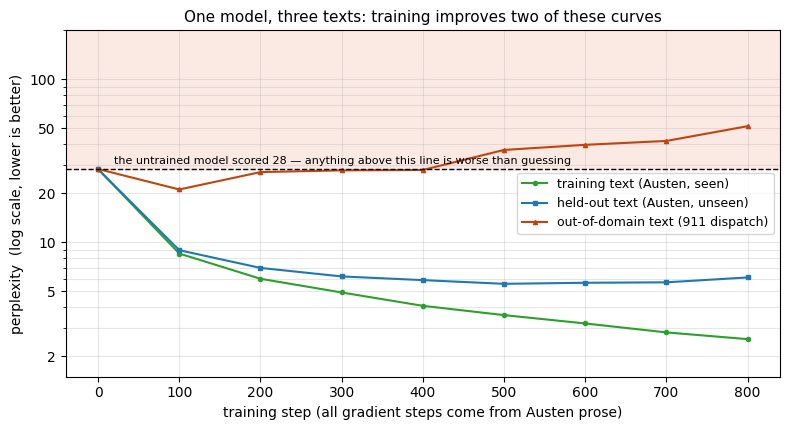

  step    train   held-out   out-of-domain
     0    28.15      28.09            28.2
   100     8.54       8.96            21.1
   200     5.98       6.98            27.0
   300     4.93       6.18            27.7
   400     4.08       5.87            27.8
   500     3.58       5.57            36.9
   600     3.18       5.65            39.7
   700     2.80       5.69            41.9
   800     2.55       6.10            51.6

held-out / training ratio at the end: 2.4x  (the generalisation gap)
out-of-domain perplexity crossed the untrained baseline of 28.0 and finished at 51.6


In [4]:
# WHAT/WHY: the four printed numbers are four snapshots of one process. Plotting
# them across training shows what a table cannot: the moment the held-out curve
# stops following the training curve (the generalisation gap opening), and the
# out-of-domain curve turning around and climbing PAST the untrained baseline.
import matplotlib.pyplot as plt

c = curve
fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.axhspan(ppl_untrained, 200, color='#fbe9e4', zorder=0)
ax.plot(c['step'], c['train'], 'o-', ms=3, color='#2ca02c', label='training text (Austen, seen)')
ax.plot(c['step'], c['val'],   's-', ms=3, color='#1f77b4', label='held-out text (Austen, unseen)')
ax.plot(c['step'], c['ood'],   '^-', ms=3, color='#c1440e', label='out-of-domain text (911 dispatch)')
ax.axhline(ppl_untrained, color='k', ls='--', lw=1)
ax.text(20, ppl_untrained * 1.08,
        f'the untrained model scored {ppl_untrained:.0f} — anything above this line is worse than guessing',
        fontsize=8)
ax.set_yscale('log')
ax.set_ylim(1.5, 200)
ax.set_yticks([2, 5, 10, 20, 50, 100]); ax.set_yticklabels(['2', '5', '10', '20', '50', '100'])
ax.set_xlabel('training step (all gradient steps come from Austen prose)')
ax.set_ylabel('perplexity  (log scale, lower is better)')
ax.set_title('One model, three texts: training improves two of these curves', fontsize=11)
ax.legend(fontsize=9, loc='center right'); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f"{'step':>6} {'train':>8} {'held-out':>10} {'out-of-domain':>15}")
for k in range(len(c['step'])):
    print(f"{c['step'][k]:>6} {c['train'][k]:>8.2f} {c['val'][k]:>10.2f} {c['ood'][k]:>15.1f}")
print(f"\nheld-out / training ratio at the end: {c['val'][-1] / c['train'][-1]:.1f}x  (the generalisation gap)")
print(f"out-of-domain perplexity crossed the untrained baseline of {ppl_untrained:.1f} "
      f"and finished at {c['ood'][-1]:.1f}")


**Read the figure.** Three curves, one model, one training run — every gradient step comes from
Austen prose, and the y-axis is log-scaled so all three fit.

- **Green (text the model trained on) falls furthest.** No surprise: it has seen this text.
- **Blue (held-out Austen) follows green down, then stops following it, then turns up.** It bottoms
  out around step 500 and edges back up; from that point every further step is improving text the
  model has seen at the cost of text it has not. The widening gap between green and blue is the
  **generalisation gap** — the part of green's improvement that is memorisation. Report the green
  number and you flatter your model by more than a factor of two.
- **Orange (911 dispatch text) goes the wrong way.** It starts level with the others — an untrained
  model is equally clueless about everything — dips slightly, then climbs for the rest of training
  and crosses the dashed line into the shaded region, where the model is **worse than the untrained
  one**. Nothing broke. Learning Austen's letter statistics *is* learning that `q` rarely follows
  `e` and that vowels come after `th`; a model that has committed to those statistics is confidently
  wrong on `ems cardiac emergency`, and confident errors cost more than ignorance.

This is the figure to remember when a vendor quotes you a perplexity. The number describes a *pair*
— this model, that text — and it changes completely when you swap either half. It is also, per Liang
et al. (2023), the number underneath AI-text detectors: low perplexity means "unsurprising to this
model", which is not the same as "written by a machine".

## 💬 Discuss

1. Our model scored **PPL 50.1 out-of-domain — worse than the untrained model's 28.0**. Explain to a non-technical manager, in three sentences, why "the trained model did worse than random" is the expected result here and not a bug.
2. Liang et al.'s detectors flag low-perplexity text as machine-written, and a Saudi student writing careful, simple English produces exactly that. Would you allow this class of tool in your institution? If a vendor came to you, what evidence would you demand before saying yes?
3. BLEU fell to **0.5779** for a sentence sharing 78% of the reference's words. Name a task where that harshness is precisely what you want, and one where it makes BLEU useless. What distinguishes them?


## ⚠️ Where this breaks

**Perplexity is not comparable across models with different tokenizers.** The number is per-token, so changing the tokenizer changes the denominator and the score. Cross-model perplexity comparisons are valid only on one fixed test set with one fixed tokenization — which is why LM papers publish both.

**Perplexity measures fit between a model and a text, never quality of either.** Our four numbers make this concrete: 28.0 untrained, **2.62 on training text**, **5.75 held out**, 50.1 out-of-domain. The 2.2× train/held-out gap is the generalisation cost; reporting the training figure would have flattered the model by more than a factor of two.

**BLEU is order-sensitive n-gram overlap.** It cannot see meaning, cannot reward a correct paraphrase, and will happily reward a fluent falsehood that reuses the reference's wording. One changed word breaks every 4-gram covering it — which is why 78% word overlap cost 42% of the score.

**Cheaper, more honest alternative when the stakes are real:** rate fifty held-out outputs by hand against a written rubric. It costs an afternoon, it is interpretable, and it will disagree with BLEU in ways you need to know about before a customer finds them. Modern practice adds semantic metrics (BERTScore) and model-graded evaluation — both of which have their own biases and neither of which removes the need for the rubric.


## 🔭 State of the field (2026)

*Field context, not examinable material — the examinable content of this lesson is everything above this box.*

BLEU and perplexity are still reported and still mean what you measured here; what changed by 2026 is that the headline number for open-ended generation is usually produced by asking another language model to grade the output — and that practice has a documented reliability problem. TrustJudge's authors identify two concrete inconsistencies in LLM-as-a-judge setups, lower-scored responses winning the pairwise comparison and circular preference chains of the form A>B>C>A, and report reducing them from 23.32% to 14.89% and from 15.22% to 4.40% with a probabilistic scoring and aggregation framework, using Llama-3.1-70B-Instruct as the judge on their own dataset (Wang et al., 2025). Because a judge has imperfect sensitivity and specificity its raw score is biased, so a 2025 plug-in framework corrects that bias against a human-labelled calibration set and builds confidence intervals carrying uncertainty from both the test set and the calibration set (Lee et al., 2025) — that is the shape a model-graded number should have before it appears in a report. Notice how little of this is new to you: a judge score is one model's measurement of a text, so it inherits precisely the lesson your four perplexity numbers taught — the number describes a **pair**, and swapping either half changes it completely. Keep BLEU and perplexity: they are deterministic, reproducible on a laptop with no API key, they are the baseline every model-graded metric has to be validated against, and decomposing a BLEU score into its length term and its order term — as you did above, 0.578 = 0.841 × 0.687 — is a diagnostic no judge hands you.

**Read:** Wang *et al.* (2025), <https://arxiv.org/abs/2509.21117> · Lee *et al.* (2025), <https://arxiv.org/abs/2511.21140> (both added to the references below).

## 📚 References & Further Reading

**Papers:**
- Papineni et al. (2002) — [BLEU](https://aclanthology.org/P02-1040/)
- Jelinek et al. (1977) — perplexity's origin in speech recognition; see also [The Gradient — Understanding Perplexity](https://thegradient.pub/understanding-evaluation-metrics-for-language-models/)

- Zhang et al. (2020) — [BERTScore: Evaluating Text Generation with BERT](https://arxiv.org/abs/1904.09675) *(ICLR 2020; the semantic-similarity metric named below)*
- Wang et al. (2025) — [TrustJudge: Inconsistencies of LLM-as-a-Judge and How to Alleviate Them](https://arxiv.org/abs/2509.21117) *(two measured failure modes of model-graded evaluation, and a framework that reduces them)*
- Lee et al. (2025) — [How to Correctly Report LLM-as-a-Judge Evaluations](https://arxiv.org/abs/2511.21140) *(bias correction against a human-labelled calibration set, plus confidence intervals — what a judge-based number should look like in a report)*
- AlQadi et al. (2026) — [Are Arabic Benchmarks Reliable? QIMMA's Quality-First Approach to LLM Evaluation](https://arxiv.org/abs/2604.03395) *(validate the benchmark before ranking anything on it: a multi-model pipeline combining automated LLM judgment with human review, yielding a curated Arabic suite of over 52k samples — the step that has to come before any score, BLEU included)*

**Beyond BLEU/perplexity:** ROUGE (summarization), BERTScore (semantic similarity), and LLM-as-judge evaluations are today's standard complements.


## 📝 Summary

In **06 — Evaluating Text Generation Quality** you computed both metrics on **real text**, never on sentences written to make the demo work.

**BLEU** was scored against a real sentence from Austen's *Emma* — `can i do any thing for you no i thank you` — with candidates selected automatically by *measured* word overlap: the closest real sentence in the same book, a moderate-overlap one, and the least-overlapping sentence in *Moby Dick*.

| candidate | word overlap | BLEU |
|---|---|---|
| identical copy | 1.00 | 1.0000 |
| closest real sentence, same book | 0.78 | 0.5779 |
| moderate-overlap real sentence | 0.22 | 0.0406 |
| unrelated real sentence (*Moby Dick*) | 0.00 | 0.0000 |

BLEU fell monotonically with overlap, as it should. The instructive part is **how steep the penalty is**: `can i do any thing for you oh` keeps 78% of the reference's words and still loses 42% of the score, because BLEU counts n-grams *in order* and one edited word breaks every 4-gram covering it. Curated candidates would have hidden that.

**Perplexity** was measured four ways on a character LM trained on real *Emma* prose. The out-of-domain text is the 911 dispatch log, read through the shared loader with `prefer="sample"`, so the 50.1 below is the bundled sample's number and is the same on every machine:

| measurement | PPL |
|---|---|
| untrained, validation text | 28.0 |
| trained, training text | 2.62 |
| trained, held-out validation | 5.75 |
| trained, out-of-domain 911 dispatch titles | 50.1 |

Real data is what makes these numbers interpretable. Untrained perplexity lands at the 29-character vocabulary size — pure guessing. In-domain perplexity settles at 5.75, **not** at 1.0: **a model reporting perplexity ≈ 1 has memorised its corpus, not learned a language**, which is exactly the false intuition a repeated toy corpus teaches. The 2.2× training-vs-held-out gap is the generalisation gap made visible. And out-of-domain perplexity (50.1) is *worse than the untrained model*: on text it never saw, the model is confidently wrong, and confident errors cost more than guessing.

Together with Unit 1's FID work (example 10), you now have the standard evaluation toolkit for generative models.
